In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

try:
    df_fromage=pd.read_csv('../data/fromages.txt', sep='\t', index_col=0)
    display(df_fromage.head())
    print(f"\nDimensions du jeu de donnees: {df_fromage.shape}")
except FileNotFoundError:
    print("Erreur: le fichier est introuvable")

,calories,sodium,calcium,lipides,retinol,folates,proteines,cholesterol,magnesium
Fromages,,,,,,,,,
CarredelEst,314,353.5,72.6,26.3,51.6,30.3,21.0,70,20
Babybel,314,238.0,209.8,25.1,63.7,6.4,22.6,70,27
Beaufort,401,112.0,259.4,33.3,54.9,1.2,26.6,120,41
Bleu,342,336.0,211.1,28.9,37.1,27.5,20.2,90,27
Camembert,264,314.0,215.9,19.5,103.0,36.4,23.4,60,20



Dimensions du jeu de donnees: (29, 9)



-- Ecart-type de chaque variables--
calories        91.914356
sodium         108.678923
calcium         72.528882
lipides          8.129642
retinol         24.163098
folates         11.723339
proteines        6.959788
cholesterol     28.245755
magnesium       11.318388
dtype: float64


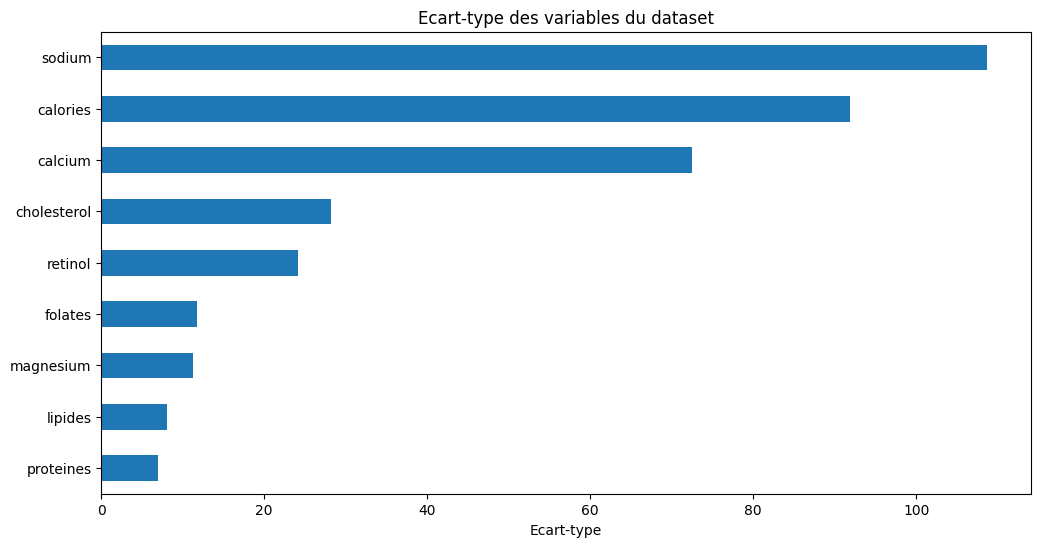

In [2]:
ecart_types =df_fromage.std()
print("\n-- Ecart-type de chaque variables--")
print(ecart_types)

plt.figure(figsize=(12, 6))
ecart_types.sort_values().plot(kind='barh')
plt.title('Ecart-type des variables du dataset')
plt.xlabel('Ecart-type')
plt.show()

**Conclusion:**
En observant les valeurs des écart-types, on constate qu'elles sont très hétérogènes. Par exemple, la variable cholesterol a un écart-type beaucoup plus élevé que lipides ou proteines. Les variables ne sont pas sur la même échelle de grandeur et n'ont pas la même dispersion.

In [3]:
print("\n -- K-Means sur le jeu de donnes(sans normalisation)--")
k=4

kmeans_brut= KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_bruts= kmeans_brut.fit_predict(df_fromage)

silhouette_brut = silhouette_score(df_fromage, clusters_bruts)
calinski_brut = calinski_harabasz_score(df_fromage, clusters_bruts)

print(f"Pour k={k} sur les donnees brutes:")
print(f" -Coefficient de sihouette: {silhouette_brut:.3f}")
print(f" -Score de Calinski-Harabasz: {calinski_brut:.3f}")


 -- K-Means sur le jeu de donnes(sans normalisation)--
Pour k=4 sur les donnees brutes:
 -Coefficient de sihouette: 0.337
 -Score de Calinski-Harabasz: 24.353



 --Classification hierachique(sans normalisation)--


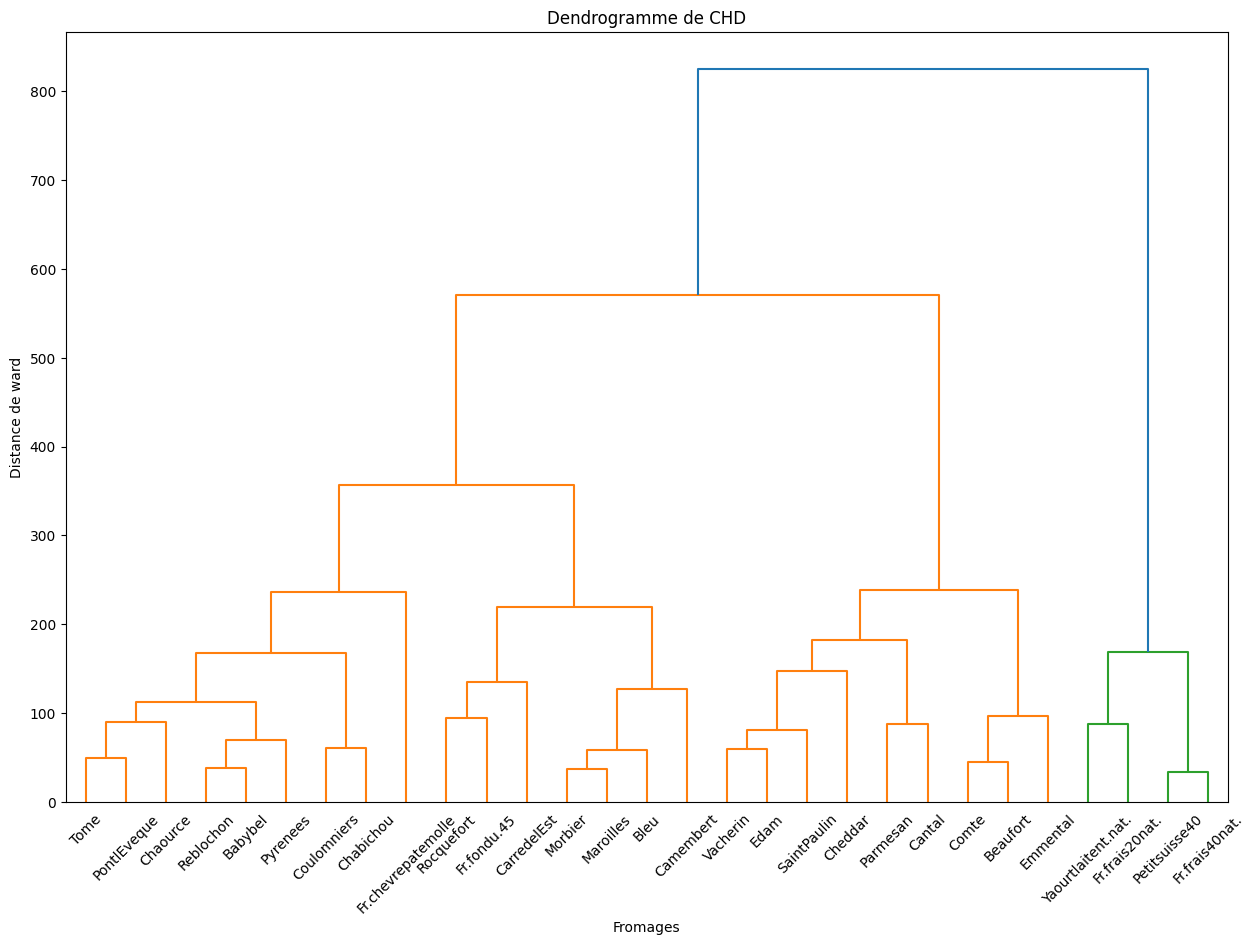

In [4]:
print("\n --Classification hierachique(sans normalisation)--")
# La matrice des liens avec la methode ward qui minimise la variance lors des fusions
linked=linkage(df_fromage, method='ward')

plt.figure(figsize=(15, 10))
dendrogram(linked,
              orientation='top',
              labels=df_fromage.index,
              distance_sort='descending',
              show_leaf_counts=True)

plt.title('Dendrogramme de CHD')
plt.ylabel("Distance de ward")
plt.xlabel("Fromages")
plt.show() 


 --Recherche du k optimal avec la methode du coude--


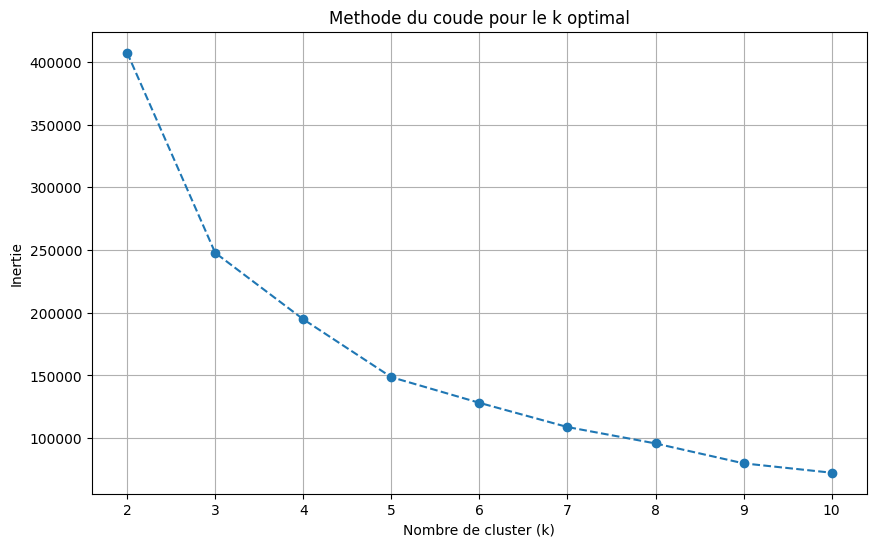

In [5]:
print("\n --Recherche du k optimal avec la methode du coude--")
inertia = []
k_range= range(2, 11)

for k in k_range:
    kmeans= KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_fromage)
    inertia.append(kmeans.inertia_) #En utilisant la sse

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Nombre de cluster (k)')
plt.ylabel('Inertie')
plt.title('Methode du coude pour le k optimal')
plt.xticks(k_range)
plt.grid(True)

**Interprétation** : Le coude est l'endroit où la courbe commence à s'aplatir. C'est le point où ajouter un nouveau cluster n'apporte plus un gain significatif en termes de compacité (réduction de l'inertie). Sur ce jeu de données, le coude est visible autour de k=3 ou k=4. 

In [6]:
print("\n-- Centrage et reduction des donnees--")
scaler=StandardScaler()
df_fromage_scaled=scaler.fit_transform(df_fromage)

df_fromage_scaled = pd.DataFrame(df_fromage_scaled, index=df_fromage.index, columns=df_fromage.columns)

moyennes_scaled=df_fromage_scaled.mean()
variances_scaled= df_fromage_scaled.var()

print("\n Moyennes des variables apres standardisation:")
print(moyennes_scaled.round(5))

print("\n Variances des variables apres standardisation:")
print(variances_scaled.round(5))


-- Centrage et reduction des donnees--

 Moyennes des variables apres standardisation:
calories      -0.0
sodium         0.0
calcium        0.0
lipides        0.0
retinol       -0.0
folates        0.0
proteines      0.0
cholesterol   -0.0
magnesium      0.0
dtype: float64

 Variances des variables apres standardisation:
calories       1.03571
sodium         1.03571
calcium        1.03571
lipides        1.03571
retinol        1.03571
folates        1.03571
proteines      1.03571
cholesterol    1.03571
magnesium      1.03571
dtype: float64



-- K-Means sur les donnees normalisees--
Pour k=4 sur le dataset(normalisé)
- Coeff de silhouette :0.345 (vs 0.337 avant)
- Score de Calinski-Harabasz: 21.460051 (vs 24.353 avant)

-- Classification hierachique sur les donnees normalisees--


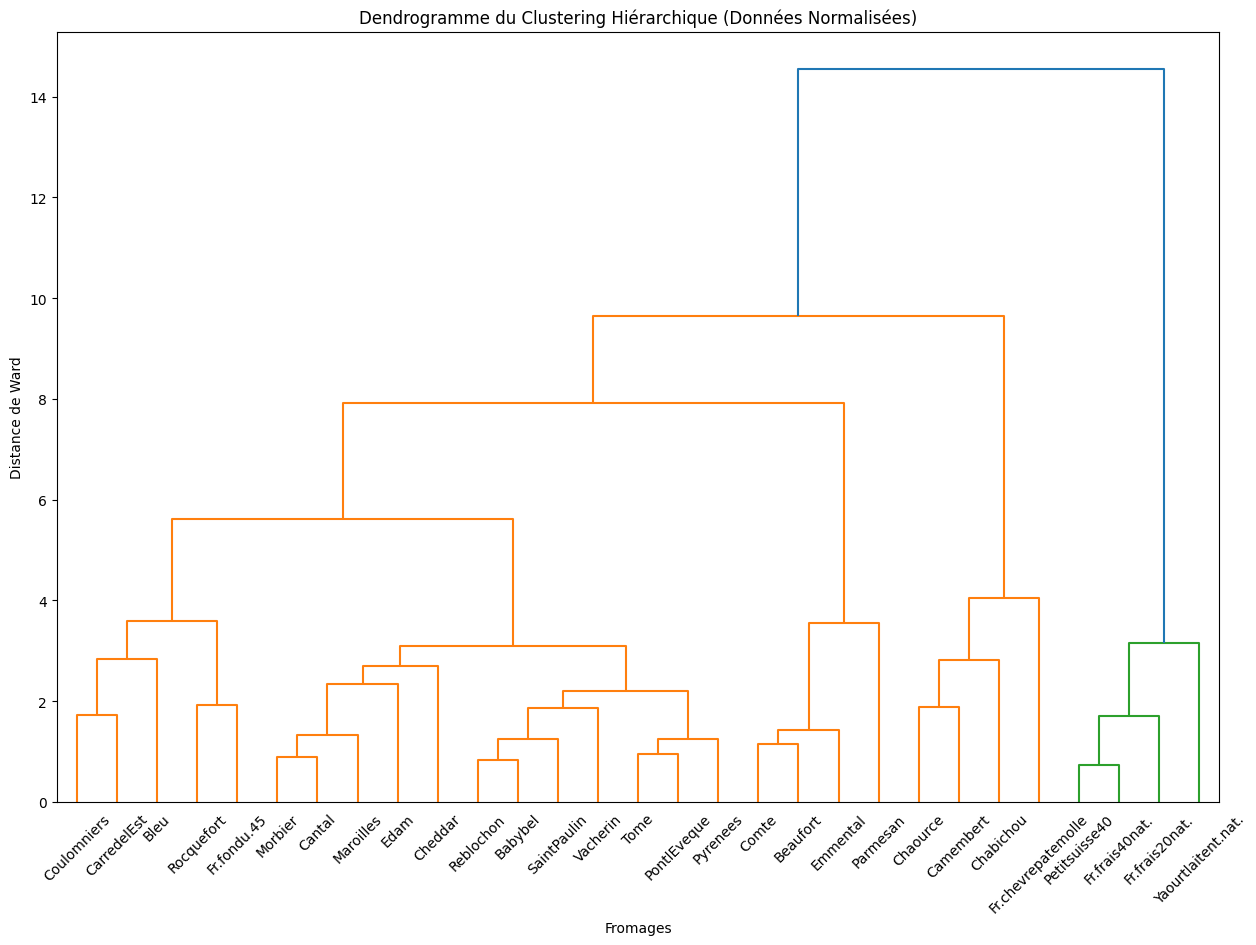

In [7]:
print("\n-- K-Means sur les donnees normalisees--")
k_opt=4

kmeans_scaled=KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters_scaled=kmeans_scaled.fit_predict(df_fromage_scaled)

silhouette_scaled=silhouette_score(df_fromage_scaled, clusters_scaled)
calinski_scaled=calinski_harabasz_score(df_fromage_scaled, clusters_scaled)


print(f"Pour k={k_opt} sur le dataset(normalisé)")
print(f"- Coeff de silhouette :{silhouette_scaled:.3f} (vs {silhouette_brut:.3f} avant)")
print(f"- Score de Calinski-Harabasz: {calinski_scaled:3F} (vs {calinski_brut:.3f} avant)")

print("\n-- Classification hierachique sur les donnees normalisees--")
linked_scaled = linkage(df_fromage_scaled, method='ward')
plt.figure(figsize=(15, 10))
dendrogram(linked_scaled,
            orientation='top',
            labels=df_fromage_scaled.index,
            distance_sort='descending',
            show_leaf_counts=True)
plt.title('Dendrogramme du Clustering Hiérarchique (Données Normalisées)')
plt.ylabel("Distance de Ward")
plt.xlabel("Fromages")
plt.show()
